# House Prices — Pré-processamento e Feature Engineering

**Objetivo:** Preparar os dados para a modelagem com base nas decisões tomadas na EDA.  
**Etapas cobertas neste notebook:**
1. Carregamento e remoção de outliers identificados na EDA
2. Tratamento de valores ausentes
3. Transformação da variável-alvo (log1p)
4. Encoding de variáveis categóricas
5. Feature engineering
6. Normalização das variáveis numéricas
7. Divisão treino/validação e exportação

## 0. Importações

In [ ]:
#!py -m pip install joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 1. Carregamento e remoção de outliers

A EDA (H1) identificou 2 outliers: casas com área > 4.000 pés² vendidas por menos de $200k.
São casos atípicos (provavelmente vendas institucionais) que distorceriam a regressão linear.

In [2]:
df = pd.read_csv('../data/train.csv')
print(f'Shape original: {df.shape}')

# Remover outliers identificados na EDA
outliers_idx = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)].index
df = df.drop(index=outliers_idx).reset_index(drop=True)

print(f'Shape após remoção de outliers: {df.shape}')
print(f'Outliers removidos: {len(outliers_idx)} (índices: {list(outliers_idx)})')

Shape original: (1460, 81)
Shape após remoção de outliers: (1458, 81)
Outliers removidos: 2 (índices: [523, 1298])


## 2. Tratamento de valores ausentes

No House Prices, a maioria dos NaN tem significado próprio:
- NaN em PoolQC, GarageType, BsmtQual etc. = ausência do atributo, não dado faltante.

Estratégia:
- Colunas com > 50% ausentes → excluir
- Categóricas restantes com NaN → preencher com 'None' (ausência do atributo)
- Numéricas com NaN → preencher com mediana da coluna

In [3]:
# Colunas com mais de 50% de ausência — excluir
pct_ausentes = df.isnull().sum() / len(df)
colunas_excluir = pct_ausentes[pct_ausentes > 0.50].index.tolist()

print('Colunas excluídas (>50% ausentes):')
for col in colunas_excluir:
    print(f'  {col}: {pct_ausentes[col]:.1%} ausentes')

df = df.drop(columns=colunas_excluir)
print(f'\nShape após exclusão: {df.shape}')

Colunas excluídas (>50% ausentes):
  Alley: 93.8% ausentes
  MasVnrType: 59.8% ausentes
  PoolQC: 99.6% ausentes
  Fence: 80.7% ausentes
  MiscFeature: 96.3% ausentes

Shape após exclusão: (1458, 76)


In [4]:
# Variáveis categóricas onde NaN = ausência do atributo
categoricas_none = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'MasVnrType'
]
# Filtrar apenas as que existem no dataframe após exclusões
categoricas_none = [c for c in categoricas_none if c in df.columns]

for col in categoricas_none:
    df[col] = df[col].fillna('None')

print(f'Colunas categóricas preenchidas com None: {len(categoricas_none)}')

Colunas categóricas preenchidas com None: 10


In [5]:
# Variáveis numéricas onde NaN = ausência do atributo (valor 0)
numericas_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
numericas_zero = [c for c in numericas_zero if c in df.columns]

for col in numericas_zero:
    df[col] = df[col].fillna(0)

print(f'Colunas numéricas preenchidas com 0: {len(numericas_zero)}')

Colunas numéricas preenchidas com 0: 10


In [6]:
# Demais variáveis categóricas → moda
cat_restantes = df.select_dtypes(include='object').columns
for col in cat_restantes:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f'  {col}: preenchido com moda = "{moda}"')

# Demais variáveis numéricas → mediana
num_restantes = df.select_dtypes(include='number').columns
for col in num_restantes:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f'  {col}: preenchido com mediana = {mediana:.1f}')

# Verificação final
total_nulos = df.isnull().sum().sum()
print(f'\nTotal de valores nulos restantes: {total_nulos}')
assert total_nulos == 0, 'Ainda há valores nulos!'

  Electrical: preenchido com moda = "SBrkr"
  LotFrontage: preenchido com mediana = 69.0

Total de valores nulos restantes: 0


## 3. Transformação da variável-alvo

Conforme decidido na EDA, SalePrice tem distribuição assimétrica.
Aplicar log1p aproxima a distribuição da normal, melhorando a performance da regressão linear.

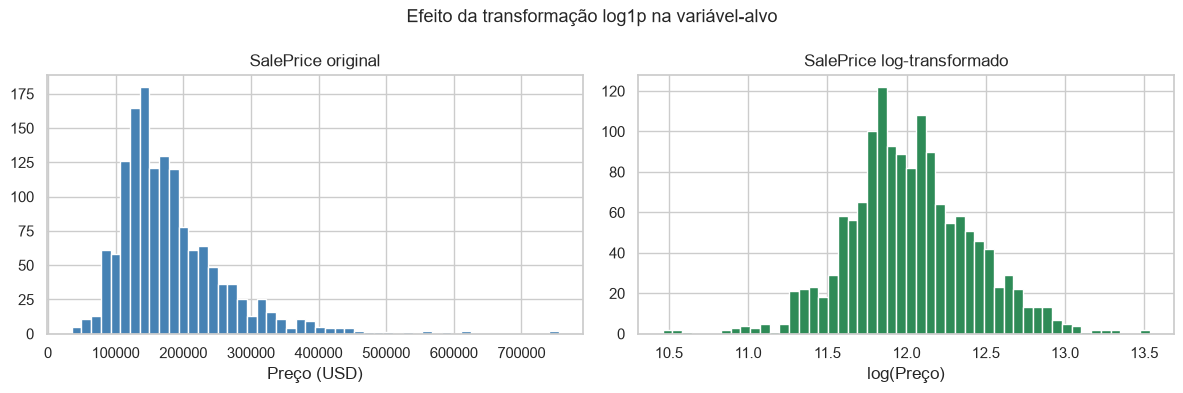

Assimetria original:       1.881
Assimetria log-transform.: 0.122


In [7]:
# Salvar o alvo original para referência
y_original = df['SalePrice'].copy()

# Transformação logarítmica
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_original, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice original')
axes[0].set_xlabel('Preço (USD)')

axes[1].hist(df['SalePrice_log'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice log-transformado')
axes[1].set_xlabel('log(Preço)')

plt.suptitle('Efeito da transformação log1p na variável-alvo', fontsize=13)
plt.tight_layout()
plt.savefig('../report/fig12_target_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Assimetria original:       {y_original.skew():.3f}')
print(f'Assimetria log-transform.: {df["SalePrice_log"].skew():.3f}')

## 4. Feature Engineering

Criar novas variáveis que combinam informações existentes e podem melhorar a performance dos modelos.
Cada nova feature tem justificativa baseada no domínio do problema.

In [8]:
# Feature 1: Área total da casa (acima + porão)
# Justificativa: área total é mais representativa que área acima do solo isolada
df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']

# Feature 2: Total de banheiros
# Justificativa: banheiros completos e lavabos têm pesos diferentes
df['TotalBaths'] = (df['FullBath'] + df['BsmtFullBath'] +
                    0.5 * (df['HalfBath'] + df['BsmtHalfBath']))

# Feature 3: Idade da casa no momento da venda
# Justificativa: YearBuilt absoluto é menos informativo que a idade relativa
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Feature 4: Anos desde a última reforma
# Justificativa: reforma recente pode compensar idade da construção
df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']

# Feature 5: Indicador de garagem (binário)
# Justificativa: confirmado na H4 da EDA como fator significativo
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

# Feature 6: Indicador de porão
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

# Feature 7: Área de varanda total
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                      df['3SsnPorch'] + df['ScreenPorch'])

novas_features = ['TotalSF', 'TotalBaths', 'HouseAge',
                  'YearsSinceRemod', 'HasGarage', 'HasBasement', 'TotalPorchSF']

print('Features criadas:')
print(df[novas_features].describe().T[['mean', 'std', 'min', 'max']].round(1))

Features criadas:
                   mean    std    min     max
TotalSF          2563.0  776.2  334.0  6872.0
TotalBaths          2.2    0.8    1.0     6.0
HouseAge           36.6   30.2    0.0   136.0
YearsSinceRemod    23.0   20.6    0.0    60.0
HasGarage           0.9    0.2    0.0     1.0
HasBasement         1.0    0.2    0.0     1.0
TotalPorchSF       86.7  104.8    0.0  1027.0


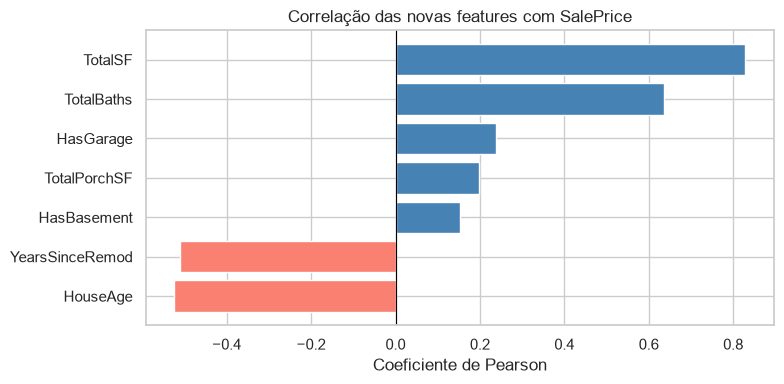

TotalSF            0.829
TotalBaths         0.636
HasGarage          0.237
TotalPorchSF       0.197
HasBasement        0.153
YearsSinceRemod   -0.510
HouseAge          -0.524


In [9]:
# Verificar correlação das novas features com SalePrice
corr_novas = df[novas_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cores = ['steelblue' if v > 0 else 'salmon' for v in corr_novas.values]
ax.barh(corr_novas.index[::-1], corr_novas.values[::-1], color=cores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação das novas features com SalePrice')
ax.set_xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.savefig('../report/fig13_novas_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_novas.round(3).to_string())

## 5. Encoding de variáveis categóricas

Modelos de ML não aceitam strings — precisamos converter categóricas em números.

Estratégia:
- Ordinais (qualidade, condição) → Label Encoding manual preservando a ordem
- Nominais (bairro, tipo de zoneamento) → One-Hot Encoding

In [10]:
# Mapeamento ordinal — preserva a ordem semântica
qualidade_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
acabamento_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
exposicao_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
tipoacab_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

colunas_qualidade = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                     'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu']
colunas_qualidade = [c for c in colunas_qualidade if c in df.columns]

for col in colunas_qualidade:
    df[col] = df[col].map(qualidade_map)

if 'GarageFinish' in df.columns:
    df['GarageFinish'] = df['GarageFinish'].map(acabamento_map)
if 'BsmtExposure' in df.columns:
    df['BsmtExposure'] = df['BsmtExposure'].map(exposicao_map)
if 'BsmtFinType1' in df.columns:
    df['BsmtFinType1'] = df['BsmtFinType1'].map(tipoacab_map)
if 'BsmtFinType2' in df.columns:
    df['BsmtFinType2'] = df['BsmtFinType2'].map(tipoacab_map)

print('Encoding ordinal aplicado.')
print(f'Colunas de qualidade mapeadas: {colunas_qualidade}')

Encoding ordinal aplicado.
Colunas de qualidade mapeadas: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu']


In [11]:
# One-Hot Encoding para variáveis nominais restantes
cat_nominais = df.select_dtypes(include='object').columns.tolist()

# Remover colunas com muitas categorias raras (> 10 categorias únicas) — simplificação
cat_para_ohe = [c for c in cat_nominais if df[c].nunique() <= 10]
cat_alta_cardinalidade = [c for c in cat_nominais if df[c].nunique() > 10]

print(f'Colunas para OHE ({len(cat_para_ohe)}): {cat_para_ohe}')
print(f'Colunas com alta cardinalidade excluídas ({len(cat_alta_cardinalidade)}): {cat_alta_cardinalidade}')

df = df.drop(columns=cat_alta_cardinalidade)
df = pd.get_dummies(df, columns=cat_para_ohe, drop_first=True)

print(f'\nShape após encoding: {df.shape}')

Colunas para OHE (22): ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'SaleType', 'SaleCondition']
Colunas com alta cardinalidade excluídas (3): ['Neighborhood', 'Exterior1st', 'Exterior2nd']

Shape após encoding: (1458, 156)


## 6. Preparação final — separar X e y, normalizar, dividir treino/validação

In [12]:
# Separar features e alvo
colunas_excluir_final = ['Id', 'SalePrice', 'SalePrice_log']
colunas_excluir_final = [c for c in colunas_excluir_final if c in df.columns]

X = df.drop(columns=colunas_excluir_final)
y = df['SalePrice_log']  # alvo log-transformado
y_original = df['SalePrice']  # alvo original para referência

# Garantir que todas as colunas são numéricas
X = X.select_dtypes(include='number')

print(f'Features (X): {X.shape}')
print(f'Alvo (y):     {y.shape}')
print(f'\nPrimeiras features:')
print(list(X.columns[:15]))

Features (X): (1458, 56)
Alvo (y):     (1458,)

Primeiras features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1']


In [13]:
# Divisão treino/validação — 80/20 com seed fixo para reprodutibilidade
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')

Treino:    1166 amostras
Validação: 292 amostras


In [14]:
# Normalização (StandardScaler) — média 0, desvio padrão 1
# Importante: fit apenas no treino, transform em ambos (evita data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

print('Normalização aplicada.')
print(f'Média após scaling (deve ser ~0): {X_train_scaled.mean().mean():.4f}')
print(f'Desvio padrão após scaling (deve ser ~1): {X_train_scaled.std().mean():.4f}')

Normalização aplicada.
Média após scaling (deve ser ~0): -0.0000
Desvio padrão após scaling (deve ser ~1): 1.0004


## 7. Exportação dos dados processados

In [15]:
import joblib

# Salvar datasets processados
X_train_scaled.to_csv('../data/X_train.csv', index=False)
X_val_scaled.to_csv('../data/X_val.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_val.to_csv('../data/y_val.csv', index=False)
y_original.to_csv('../data/y_original.csv', index=False)

# Salvar o scaler para uso no dashboard
joblib.dump(scaler, '../data/scaler.pkl')

# Salvar lista de features para uso no notebook 03 e dashboard
pd.Series(X.columns.tolist()).to_csv('../data/feature_names.csv', index=False)

print('Arquivos exportados:')
print('  ../data/X_train.csv')
print('  ../data/X_val.csv')
print('  ../data/y_train.csv')
print('  ../data/y_val.csv')
print('  ../data/y_original.csv')
print('  ../data/scaler.pkl')
print('  ../data/feature_names.csv')
print(f'\nTotal de features para modelagem: {X.shape[1]}')
print('Notebook 02_preprocessing concluído.')

Arquivos exportados:
  ../data/X_train.csv
  ../data/X_val.csv
  ../data/y_train.csv
  ../data/y_val.csv
  ../data/y_original.csv
  ../data/scaler.pkl
  ../data/feature_names.csv

Total de features para modelagem: 56
Notebook 02_preprocessing concluído.
